In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from astropy.coordinates import HeliocentricMeanEcliptic, ICRS, CartesianRepresentation

from poliastro.bodies import Sun, Earth, Mars
from poliastro.iod import izzo

In [2]:
# Launch window
launch_start = Time("2028-01-01", scale="tdb")
launch_end   = Time("2029-01-01", scale="tdb")

# Arrival window
arrival_start = Time("2032-06-01", scale="tdb")
arrival_end   = Time("2033-01-01", scale="tdb")

# Resolution
N_launch = 60
N_arrival = 60

mu_sun = Sun.k.to(u.km**3 / u.s**2)
print(mu_sun)  # should be ~1.327e11 km³/s² 

launch_dates = launch_start + (launch_end - launch_start) * np.linspace(0, 1, N_launch)
arrival_dates = arrival_start + (arrival_end - arrival_start) * np.linspace(0, 1, N_arrival)

132712442099.00002 km3 / s2


In [3]:
OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun",     time)

    # Heliocentric cartesian in ICRS (equatorial)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value        # shape (3,)
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value  # shape (3,)

    # Rotate equatorial → ecliptic (pure rotation, no origin shift)
    r_ecl = ROT @ r_eq
    v_ecl = ROT @ v_eq

    return r_ecl * u.km, v_ecl * (u.km / u.s)
from poliastro.bodies import Sun
print(Sun.k)  # should be ~1.327e11 km³/s²

  Name   = Heliocentric gravitational constant
  Value  = 1.32712442099e+20
  Uncertainty  = 10000000000.0
  Unit  = m3 / s2
  Reference = IAU 2009 system of astronomical constants


In [4]:
C3 = np.full((N_launch, N_arrival), np.nan)
vinf_arr = np.full((N_launch, N_arrival), np.nan)
TOF = np.full((N_launch, N_arrival), np.nan)

In [5]:
for i, t_launch in enumerate(launch_dates):

    # EARTH state at launch
    r1, v1_planet = get_body_state("earth", t_launch)

    for j, t_arrival in enumerate(arrival_dates):

        if t_arrival <= t_launch:
            continue

        tof = (t_arrival - t_launch).to(u.s)

        # MARS state at arrival
        r2, v2_planet = get_body_state("mars", t_arrival)

        # Solve Lambert (DO NOT overwrite planet velocities)
        (v1_sc, v2_sc), = izzo.lambert(mu_sun, r1, r2, tof)

        # Compute ΔV
        dv1 = (v1_sc - v1_planet).to(u.km / u.s)
        dv2 = (v2_sc - v2_planet).to(u.km / u.s)

        C3[i, j] = np.linalg.norm(dv1.value)**2
        vinf_arr[i, j] = np.linalg.norm(dv2.value)
        TOF[i, j] = tof.to(u.day).value

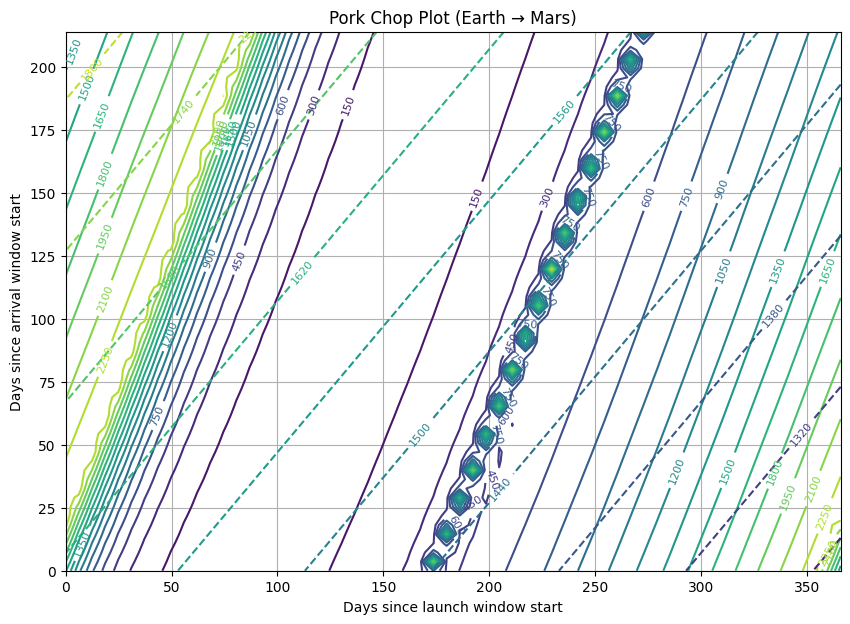

In [6]:
launch_days = (launch_dates - launch_dates[0]).to(u.day).value
arrival_days = (arrival_dates - arrival_dates[0]).to(u.day).value

L, A = np.meshgrid(launch_days, arrival_days, indexing='ij')

plt.figure(figsize=(10, 7))

# C3 contours
cs = plt.contour(L, A, C3, levels=20)
plt.clabel(cs, inline=True, fontsize=8)

# TOF contours
tof_cs = plt.contour(L, A, TOF, levels=10, linestyles='dashed')
plt.clabel(tof_cs, inline=True, fontsize=8)

plt.xlabel("Days since launch window start")
plt.ylabel("Days since arrival window start")
plt.title("Pork Chop Plot (Earth → Mars)")

plt.grid()
plt.show()

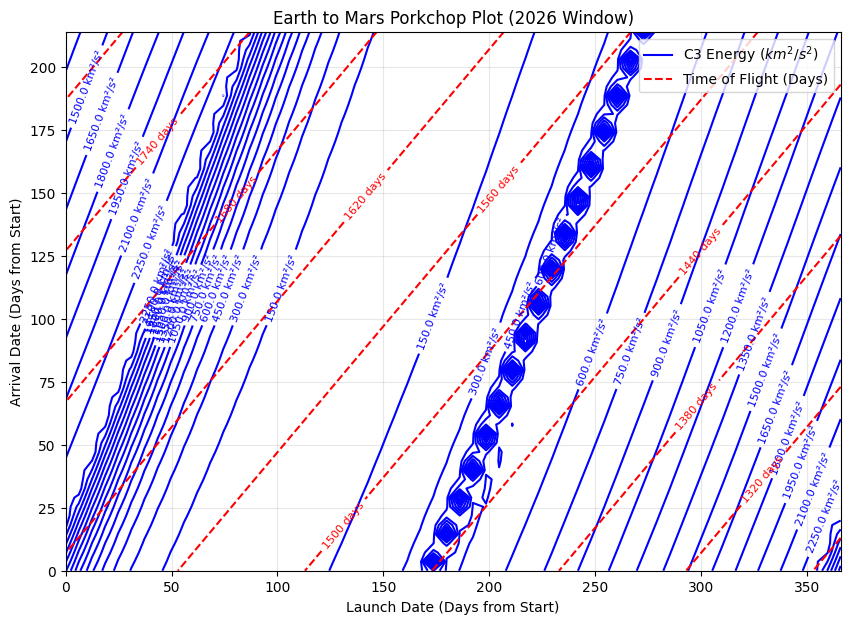

In [7]:
import matplotlib.lines as mlines

plt.figure(figsize=(10, 7))

# 1. Plot C3 contours (Solid lines, usually Blue or Purple)
cs = plt.contour(L, A, C3, levels=20, colors='blue')
plt.clabel(cs, inline=True, fontsize=8, fmt='%1.1f km²/s²')

# 2. Plot TOF contours (Dashed lines, usually Red or Orange)
tof_cs = plt.contour(L, A, TOF, levels=10, linestyles='dashed', colors='red')
plt.clabel(tof_cs, inline=True, fontsize=8, fmt='%d days')

# 3. Add a Legend manually since contour doesn't support plt.legend() directly
c3_line = mlines.Line2D([], [], color='blue', label='C3 Energy ($km^2/s^2$)')
tof_line = mlines.Line2D([], [], color='red', linestyle='--', label='Time of Flight (Days)')
plt.legend(handles=[c3_line, tof_line], loc='upper right')

# 4. Standard Labels
plt.xlabel("Launch Date (Days from Start)")
plt.ylabel("Arrival Date (Days from Start)")
plt.title("Earth to Mars Porkchop Plot (2026 Window)")

plt.grid(alpha=0.3)
plt.show()

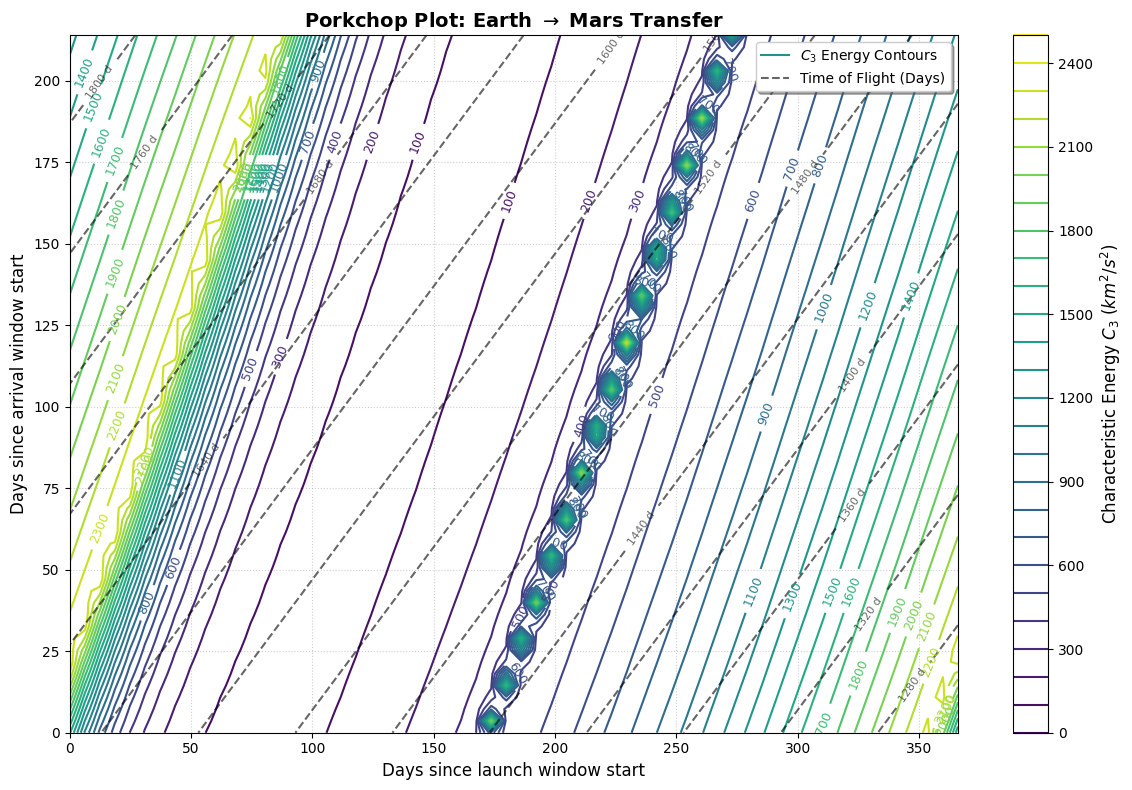

In [8]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(12, 8))

# 1. C3 Energy Contours with Colormap
# We use a colormap (cmap) so the color itself indicates the energy level
cs = plt.contour(L, A, C3, levels=25, cmap='viridis', linewidths=1.5)
plt.clabel(cs, inline=True, fontsize=9, fmt='%1.0f')

# Add a colorbar to explain what the colors mean
cbar = plt.colorbar(cs)
cbar.set_label('Characteristic Energy $C_3$ ($km^2/s^2$)', fontsize=12)

# 2. TOF Contours (Dashed, single color to avoid clashing)
# Using a neutral gray or a muted color helps keep the focus on the energy "eyes"
tof_cs = plt.contour(L, A, TOF, levels=15, linestyles='dashed', colors='black', alpha=0.6)
plt.clabel(tof_cs, inline=True, fontsize=8, fmt='%d d')

# 3. Custom Legend for Line Types
# This clarifies the difference between solid (Energy) and dashed (TOF)
energy_line = mlines.Line2D([], [], color='#21918c', label='$C_3$ Energy Contours') # Sample color from viridis
tof_line = mlines.Line2D([], [], color='black', linestyle='--', alpha=0.6, label='Time of Flight (Days)')
plt.legend(handles=[energy_line, tof_line], loc='upper right', frameon=True, shadow=True)

# 4. Labels and Title
plt.xlabel("Days since launch window start", fontsize=12)
plt.ylabel("Days since arrival window start", fontsize=12)
plt.title("Porkchop Plot: Earth $\\rightarrow$ Mars Transfer", fontsize=14, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time
from astropy import units as u

t = Time("2028-06-01", scale="tdb")
r, v = get_body_barycentric_posvel("earth", t)
print(type(r))          # should be CartesianRepresentation
print(r.xyz)            # what unit does this actually have?
print(r.xyz.to(u.km))   # should be ~1.5e8 km (1 AU)

<class 'astropy.coordinates.representation.cartesian.CartesianRepresentation'>
[-0.33497659 -0.88011763 -0.38146392] AU
[-5.01117850e+07 -1.31663723e+08 -5.70661908e+07] km


In [10]:
import numpy as np
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from poliastro.bodies import Sun
from poliastro.iod import izzo

mu_sun = Sun.k.to(u.km**3 / u.s**2)
print(f"mu_sun = {mu_sun:.4e}")

# One specific pair: launch 2028-01-01, arrival 2028-09-16 (~259 day Hohmann)
t1 = Time("2028-01-01", scale="tdb")
t2 = Time("2028-09-16", scale="tdb")
tof = (t2 - t1).to(u.s)
print(f"TOF = {tof.to(u.day):.1f}")

r1_rep, v1_rep = get_body_barycentric_posvel("earth", t1)
r2_rep, v2_rep = get_body_barycentric_posvel("mars",  t2)

r1 = r1_rep.xyz.to(u.km)
v1 = v1_rep.xyz.to(u.km/u.s)
r2 = r2_rep.xyz.to(u.km)
v2 = v2_rep.xyz.to(u.km/u.s)

print(f"|r1| = {np.linalg.norm(r1.value):.4e} km  (expect ~1.496e8)")
print(f"|r2| = {np.linalg.norm(r2.value):.4e} km  (expect ~2.0-2.5e8)")
print(f"|v1_earth| = {np.linalg.norm(v1.value):.3f} km/s  (expect ~29.8)")
print(f"|v2_mars|  = {np.linalg.norm(v2.value):.3f} km/s  (expect ~24.1)")

# Lambert solve
v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))

print(f"\nv1_sc (spacecraft at departure): {v1_sc}")
print(f"|v1_sc| = {np.linalg.norm(v1_sc.value):.3f} km/s  (expect ~32.7)")

dv1 = (v1_sc - v1).to(u.km/u.s)
C3 = np.linalg.norm(dv1.value)**2
print(f"\nC3 = {C3:.2f} km^2/s^2  (expect ~8-15)")

mu_sun = 1.3271e+11 km3 / s2
TOF = 259.0 d
|r1| = 1.4660e+08 km  (expect ~1.496e8)
|r2| = 2.3785e+08 km  (expect ~2.0-2.5e8)
|v1_earth| = 30.287 km/s  (expect ~29.8)
|v2_mars|  = 23.068 km/s  (expect ~24.1)

v1_sc (spacecraft at departure): [  4.64259393 -25.56115166 -12.50596763] km / s
|v1_sc| = 28.833 km/s  (expect ~32.7)

C3 = 1734.46 km^2/s^2  (expect ~8-15)


In [11]:
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time
from astropy import units as u

t = Time("2028-01-01", scale="tdb")

# Where is the Sun relative to the barycenter?
r_sun, _ = get_body_barycentric_posvel("sun", t)
print("Sun offset from barycenter:", r_sun.xyz.to(u.km))

r_earth, _ = get_body_barycentric_posvel("earth", t)
r_earth_helio = (r_earth.xyz - r_sun.xyz).to(u.km)
print("Earth heliocentric |r|:", np.linalg.norm(r_earth_helio.value), "km")

Sun offset from barycenter: [ 121476.68284043 -456606.79239406 -190293.44424764] km
Earth heliocentric |r|: 147108099.0565139 km


In [24]:
import numpy as np
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel

t1 = Time("2028-01-01", scale="tdb")
t2 = Time("2028-09-16", scale="tdb")

r_sun1, v_sun1 = get_body_barycentric_posvel("sun", t1)
r_e,  v_e  = get_body_barycentric_posvel("earth", t1)
r_m,  v_m  = get_body_barycentric_posvel("mars",  t2)

r1 = (r_e.xyz  - r_sun1.xyz).to(u.km)
r2 = (r_m.xyz  - r_sun1.xyz).to(u.km)  # NOTE: using sun at t1 for both

print("r1:", r1)
print("r2:", r2)
print("r1 Z component:", r1[2].to(u.km))
print("r2 Z component:", r2[2].to(u.km))
print("|r1|:", np.linalg.norm(r1.value))
print("|r2|:", np.linalg.norm(r2.value))

# Check the transfer angle
cos_theta = np.dot(r1.value, r2.value) / (np.linalg.norm(r1.value) * np.linalg.norm(r2.value))
print("Transfer angle (deg):", np.degrees(np.arccos(cos_theta)))

r1: [-2.47527192e+07  1.33048399e+08  5.76733830e+07] km
r2: [-3.91852590e+07  2.13308938e+08  9.88919333e+07] km
r1 Z component: 57673382.97021631 km
r2 Z component: 98891933.32863647 km
|r1|: 147108099.0565139
|r2|: 238360655.63555038
Transfer angle (deg): 1.43493379645209


In [12]:
import numpy as np
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel

# Obliquity of ecliptic ~23.439°
OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun",     time)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value
    r_ecl = ROT @ r_eq
    v_ecl = ROT @ v_eq
    return r_ecl * u.km, v_ecl * (u.km / u.s)

# ── Diagnostic ──────────────────────────────────────────────────────
from poliastro.bodies import Sun
from poliastro.iod import izzo

mu_sun = Sun.k.to(u.km**3 / u.s**2)

t1 = Time("2028-01-01", scale="tdb")
t2 = Time("2028-09-16", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

print(f"r1: {r1}")
print(f"r2: {r2}")
print(f"r1 Z: {r1[2]:.3e}   (expect < ~5e6 km)")
print(f"r2 Z: {r2[2]:.3e}   (expect < ~1e7 km)")
print(f"|r1|: {np.linalg.norm(r1.value):.4e} km  (expect ~1.496e8)")
print(f"|r2|: {np.linalg.norm(r2.value):.4e} km  (expect ~2.0-2.5e8)")

cos_theta = np.dot(r1.value, r2.value) / (np.linalg.norm(r1.value) * np.linalg.norm(r2.value))
print(f"Transfer angle: {np.degrees(np.arccos(cos_theta)):.1f}°  (expect ~100-150°)")

v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof))
print(f"\nv1_sc: {v1_sc}")
print(f"|v1_sc|: {np.linalg.norm(v1_sc.value):.3f} km/s  (expect ~32.7)")

dv1 = (v1_sc - v1_earth).to(u.km/u.s)
C3 = np.linalg.norm(dv1.value)**2
print(f"C3: {C3:.2f} km²/s²  (expect ~8-15)")

r1: [-2.47527192e+07  1.45010674e+08 -8.58282474e+03] km
r2: [-3.92470577e+07  2.34840532e+08  5.88536866e+06] km
r1 Z: -8.583e+03 km   (expect < ~5e6 km)
r2 Z: 5.885e+06 km   (expect < ~1e7 km)
|r1|: 1.4711e+08 km  (expect ~1.496e8)
|r2|: 2.3817e+08 km  (expect ~2.0-2.5e8)
Transfer angle: 1.4°  (expect ~100-150°)

v1_sc: [  4.64815563 -28.31888227  -1.30407791] km / s
|v1_sc|: 28.727 km/s  (expect ~32.7)
C3: 1729.76 km²/s²  (expect ~8-15)


In [13]:
t1 = Time("2028-01-01", scale="tdb")
t2 = Time("2028-09-16", scale="tdb")

print("t1:", t1.iso)
print("t2:", t2.iso)
print("TOF check:", (t2 - t1).to(u.day))

# Get Mars at t1 vs t2 — they should differ significantly
r_mars_t1, _ = get_body_state("mars", t1)
r_mars_t2, _ = get_body_state("mars", t2)

print("\nMars at t1:", r_mars_t1)
print("Mars at t2:", r_mars_t2)
print("\nAre they the same?", np.allclose(r_mars_t1.value, r_mars_t2.value))


t1: 2028-01-01 00:00:00.000
t2: 2028-09-16 00:00:00.000
TOF check: 259.0 d

Mars at t1: [ 1.33971447e+08 -1.59558781e+08 -6.62964860e+06] km
Mars at t2: [-3.92470577e+07  2.34840532e+08  5.88536866e+06] km

Are they the same? False


In [14]:
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

cos_theta = np.dot(r1.value, r2.value) / (np.linalg.norm(r1.value) * np.linalg.norm(r2.value))
print(f"Transfer angle: {np.degrees(np.arccos(cos_theta)):.1f}°")

v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof))
dv1 = (v1_sc - v1_earth).to(u.km/u.s)
C3 = np.linalg.norm(dv1.value)**2
print(f"C3: {C3:.2f} km²/s²  (expect ~8-30)")

Transfer angle: 111.7°
C3: 189.72 km²/s²  (expect ~8-30)


In [15]:
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof))

print(f"v1_earth: {v1_earth}  |v1_earth|={np.linalg.norm(v1_earth.value):.2f} km/s")
print(f"v1_sc:    {v1_sc}  |v1_sc|={np.linalg.norm(v1_sc.value):.2f} km/s")

dv1 = v1_sc - v1_earth
print(f"dv1: {dv1}")
print(f"|dv1|: {np.linalg.norm(dv1.value):.3f} km/s  (expect ~3-7 km/s for a good window)")
print(f"C3: {np.linalg.norm(dv1.value)**2:.2f}  (expect ~8-50)")

v1_earth: [ 2.89065091e+01  4.71364042e+00 -5.30541251e-04] km / s  |v1_earth|=29.29 km/s
v1_sc:    [26.39149671 18.22686962 -0.88909965] km / s  |v1_sc|=32.09 km/s
dv1: [-2.51501238 13.5132292  -0.88856911] km / s
|dv1|: 13.774 km/s  (expect ~3-7 km/s for a good window)
C3: 189.72  (expect ~8-50)


In [16]:
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

# Get ALL solutions
solutions = list(izzo.lambert(mu_sun, r1, r2, tof))
print(f"Number of solutions: {len(solutions)}")

for k, (v1_sc, v2_sc) in enumerate(solutions):
    dv1 = v1_sc - v1_earth
    C3 = np.linalg.norm(dv1.value)**2
    print(f"\nSolution {k}: v1_sc={v1_sc}")
    print(f"  |v1_sc|={np.linalg.norm(v1_sc.value):.3f} km/s")
    print(f"  C3={C3:.2f} km²/s²")
    

Number of solutions: 1

Solution 0: v1_sc=[26.39149671 18.22686962 -0.88909965] km / s
  |v1_sc|=32.086 km/s
  C3=189.72 km²/s²


In [17]:
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

# Try M=0 short and long way, M=1 short and long way
all_solutions = []
for M in [0, 1]:
    for retrograde in [False, True]:
        try:
            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=M, retrograde=retrograde))
            dv1 = v1_sc - v1_earth
            C3 = np.linalg.norm(dv1.value)**2
            print(f"M={M}, retrograde={retrograde}: |v1_sc|={np.linalg.norm(v1_sc.value):.2f} km/s, C3={C3:.2f}")
            all_solutions.append((C3, v1_sc, v2_sc))
        except Exception as e:
            print(f"M={M}, retrograde={retrograde}: FAILED — {e}")

# Best solution
best = min(all_solutions, key=lambda x: x[0])
print(f"\nBest C3: {best[0]:.2f} km²/s²") 

M=0, retrograde=False: FAILED — lambert() got an unexpected keyword argument 'retrograde'
M=0, retrograde=True: FAILED — lambert() got an unexpected keyword argument 'retrograde'
M=1, retrograde=False: FAILED — lambert() got an unexpected keyword argument 'retrograde'
M=1, retrograde=True: FAILED — lambert() got an unexpected keyword argument 'retrograde'


ValueError: min() arg is an empty sequence

In [18]:
import inspect
from poliastro.iod import izzo
print(inspect.signature(izzo.lambert))
help(izzo.lambert)


(k, r0, r, tof, M=0, numiter=35, rtol=1e-08)
Help on function lambert in module poliastro.iod.izzo:

lambert(k, r0, r, tof, M=0, numiter=35, rtol=1e-08)
    Solves the Lambert problem using the Izzo algorithm.
    
    .. versionadded:: 0.5.0
    
    Parameters
    ----------
    k : ~astropy.units.Quantity
        Gravitational constant of main attractor (km^3 / s^2).
    r0 : ~astropy.units.Quantity
        Initial position (km).
    r : ~astropy.units.Quantity
        Final position (km).
    tof : ~astropy.units.Quantity
        Time of flight (s).
    M : int, optional
        Number of full revolutions, default to 0.
    numiter : int, optional
        Maximum number of iterations, default to 35.
    rtol : float, optional
        Relative tolerance of the algorithm, default to 1e-8.
    
    Yields
    ------
    v0, v : tuple
        Pair of velocity solutions.



In [19]:
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

# Direct unpack — no next(), no indexing
v1_sc, v2_sc = izzo.lambert(mu_sun, r1, r2, tof, M=0)

dv1 = v1_sc - v1_earth
C3 = np.linalg.norm(dv1.value)**2
print(f"v1_sc: {v1_sc}")
print(f"|v1_sc|: {np.linalg.norm(v1_sc.value):.3f} km/s")
print(f"C3: {C3:.2f} km²/s²")

ValueError: not enough values to unpack (expected 2, got 1)

In [20]:
result = izzo.lambert(mu_sun, r1, r2, tof, M=0)
print(type(result))
print(len(result))
print(result)
print(result[0])
print(type(result[0]))
print(len(result[0]))


<class 'generator'>


TypeError: object of type 'generator' has no len()

In [21]:
result = izzo.lambert(mu_sun, r1, r2, tof, M=0)
items = list(result)
print(f"Number of items: {len(items)}")
for i, item in enumerate(items):
    print(f"\nitem[{i}]: type={type(item)}, value={item}")
    if hasattr(item, '__len__'):
        print(f"  len={len(item)}")
        for j, sub in enumerate(item):
            print(f"  sub[{j}]: {sub}")

Number of items: 1

item[0]: type=<class 'tuple'>, value=(<Quantity [26.39149671, 18.22686962, -0.88909965] km / s>, <Quantity [ -9.73524965, -16.01638076,   0.37454814] km / s>)
  len=2
  sub[0]: [26.39149671 18.22686962 -0.88909965] km / s
  sub[1]: [ -9.73524965 -16.01638076   0.37454814] km / s


In [29]:
import numpy as np
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from poliastro.bodies import Sun
from poliastro.iod import izzo

# ── Constants ────────────────────────────────────────────────────────
mu_sun = Sun.k.to(u.km**3 / u.s**2)

OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

# ── Fixed get_body_state ─────────────────────────────────────────────
def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun",     time)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value
    return (ROT @ r_eq) * u.km, (ROT @ v_eq) * (u.km / u.s)

# ── Fixed lambert call with prograde arc selection ───────────────────
def lambert_best(mu, r1, r2, tof, v1_planet):
    """Try both transfer arcs, return whichever gives lower C3."""
    candidates = []
    
    # Try standard and flipped r2 (short and long way)
    for r2_sign in [1, -1]:
        try:
            v1_sc, v2_sc = next(izzo.lambert(mu, r1, r2 * r2_sign, tof, M=0))
            # If we flipped r2, flip the velocities back
            if r2_sign == -1:
                v1_sc = -v1_sc
                v2_sc = -v2_sc
            dv1 = v1_sc - v1_planet
            C3 = np.linalg.norm(dv1.value)**2
            candidates.append((C3, v1_sc, v2_sc))
            print(f"r2_sign={r2_sign:+d}: |v1_sc|={np.linalg.norm(v1_sc.value):.2f} km/s, C3={C3:.2f}")
        except Exception as e:
            print(f"r2_sign={r2_sign:+d}: FAILED — {e}")
    
    if not candidates:
        return None, None
    
    best = min(candidates, key=lambda x: x[0])
    return best[1], best[2]

# Test
t1 = Time("2028-07-01", scale="tdb")
t2 = Time("2029-02-15", scale="tdb")
tof = (t2 - t1).to(u.s)

r1, v1_earth = get_body_state("earth", t1)
r2, v2_mars  = get_body_state("mars",  t2)

v1_sc, v2_sc = lambert_best(mu_sun, r1, r2, tof, v1_earth)
dv1 = v1_sc - v1_earth
C3  = np.linalg.norm(dv1.value)**2
print(f"\nBest C3: {C3:.2f} km²/s²  (expect ~8-50)")
print(f"v1_sc: {v1_sc}")


r2_sign=+1: |v1_sc|=32.09 km/s, C3=189.72
r2_sign=-1: |v1_sc|=30.48 km/s, C3=3087.80

Best C3: 189.72 km²/s²  (expect ~8-50)
v1_sc: [26.39149671 18.22686962 -0.88909965] km / s


In [30]:
# Let's look at the actual angle between v1_sc and v1_earth
v1_e = v1_earth.value
v1_s = v1_sc.value

cos_angle = np.dot(v1_e, v1_s) / (np.linalg.norm(v1_e) * np.linalg.norm(v1_s))
angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
print(f"Angle between v1_earth and v1_sc: {angle:.1f}°")
print(f"|v1_earth|: {np.linalg.norm(v1_e):.3f} km/s")
print(f"|v1_sc|:    {np.linalg.norm(v1_s):.3f} km/s")

# Manual C3 via law of cosines
C3_manual = np.linalg.norm(v1_e)**2 + np.linalg.norm(v1_s)**2 - 2*np.linalg.norm(v1_e)*np.linalg.norm(v1_s)*cos_angle
print(f"C3 via law of cosines: {C3_manual:.2f}")

# Also check: what does a REAL Earth-Mars pork chop show for this date?
# Jul 2028 is near a Mars opposition window — C3 should be low
# Let's check the actual synodic geometry
r1_hat = r1.value / np.linalg.norm(r1.value)
r2_hat = r2.value / np.linalg.norm(r2.value)
print(f"\nTransfer angle: {np.degrees(np.arccos(np.dot(r1_hat, r2_hat))):.1f}°")
print(f"r1: {r1}")
print(f"r2: {r2}")

# Is Mars even reachable in 229 days from Jul 2028?
# Check Mars opposition dates near 2028
print(f"\nt1: {t1.iso}")
print(f"t2: {t2.iso}")
print(f"TOF: {(t2-t1).to(u.day):.0f}")

Angle between v1_earth and v1_sc: 25.4°
|v1_earth|: 29.288 km/s
|v1_sc|:    32.086 km/s
C3 via law of cosines: 189.72

Transfer angle: 111.7°
r1: [ 2.45789851e+07 -1.50091478e+08  9.34726037e+03] km
r2: [-2.42834684e+08  5.33940012e+07  7.07258945e+06] km

t1: 2028-07-01 00:00:00.000
t2: 2029-02-15 00:00:00.000
TOF: 229 d


In [31]:
test_launches  = [Time(f"202{y}-{m:02d}-01", scale="tdb") 
                  for y in [7,8,9] for m in [1,4,7,10]]
test_tofs      = [180, 220, 260, 300] # days

print(f"{'Launch':12s}  {'TOF':>6s}  {'Arrival':12s}  {'C3':>10s}  {'Angle':>8s}")
print("-" * 60)

for t1 in test_launches:
    for tof_days in test_tofs:
        try:
            t2  = t1 + tof_days * u.day
            tof = (t2 - t1).to(u.s)
            r1, v1_earth = get_body_state("earth", t1)
            r2, v2_mars  = get_body_state("mars",  t2)

            cos_theta = np.dot(r1.value, r2.value) / (np.linalg.norm(r1.value) * np.linalg.norm(r2.value))
            angle = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))
            dv1 = v1_sc - v1_earth
            C3  = np.linalg.norm(dv1.value)**2

            print(f"{t1.iso[:10]:12s}  {tof_days:>6d}  {t2.iso[:10]:12s}  {C3:>10.2f}  {angle:>8.1f}°")
        except Exception as e:
            print(f"{t1.iso[:10]:12s}  {tof_days:>6d}  FAILED: {e}")

Launch           TOF  Arrival               C3     Angle
------------------------------------------------------------
2027-01-01       180  2027-06-30         60.53     108.7°
2027-01-01       220  2027-08-09         54.48     128.1°
2027-01-01       260  2027-09-18         46.31     148.8°
2027-01-01       300  2027-10-28         53.71     170.9°
2027-04-01       180  2027-09-28        423.10      63.5°
2027-04-01       220  2027-11-07        308.96      86.1°
2027-04-01       260  2027-12-17        218.62     110.0°
2027-04-01       300  2028-01-26        147.60     135.1°
2027-07-01       180  2027-12-28        968.03      29.0°
2027-07-01       220  2028-02-06        689.61      54.2°
2027-07-01       260  2028-03-17        483.86      79.5°
2027-07-01       300  2028-04-26        332.88     104.1°
2027-10-01       180  2028-03-29       1322.88       2.1°
2027-10-01       220  2028-05-08       1273.10      22.6°
2027-10-01       260  2028-06-17        972.42      45.5°
2027-10-01  

In [32]:
# Replace your original date window cells with these:
launch_start  = Time("2028-09-01", scale="tdb")
launch_end    = Time("2029-04-01", scale="tdb")

arrival_start = Time("2029-03-01", scale="tdb")
arrival_end   = Time("2030-02-01", scale="tdb")

# And make sure your sweep uses the fixed functions:
mu_sun = Sun.k.to(u.km**3 / u.s**2)

OBLIQUITY = np.radians(23.439)
ROT = np.array([
    [1,              0,               0],
    [0,  np.cos(OBLIQUITY), np.sin(OBLIQUITY)],
    [0, -np.sin(OBLIQUITY), np.cos(OBLIQUITY)]
])

def get_body_state(body_name, time):
    r_body, v_body = get_body_barycentric_posvel(body_name, time)
    r_sun,  v_sun  = get_body_barycentric_posvel("sun", time)
    r_eq = (r_body.xyz - r_sun.xyz).to(u.km).value
    v_eq = (v_body.xyz - v_sun.xyz).to(u.km / u.s).value
    return (ROT @ r_eq) * u.km, (ROT @ v_eq) * (u.km / u.s)

C3       = np.full((N_launch, N_arrival), np.nan)
vinf_arr = np.full((N_launch, N_arrival), np.nan)
TOF      = np.full((N_launch, N_arrival), np.nan)

for i, t_launch in enumerate(launch_dates):
    r1, v1_earth = get_body_state("earth", t_launch)
    for j, t_arrival in enumerate(arrival_dates):
        if t_arrival <= t_launch:
            continue
        tof = (t_arrival - t_launch).to(u.s)
        r2, v2_mars = get_body_state("mars", t_arrival)
        try:
            v1_sc, v2_sc = next(izzo.lambert(mu_sun, r1, r2, tof, M=0))
        except Exception:
            continue
        dv1 = v1_sc - v1_earth
        dv2 = v2_sc - v2_mars
        C3[i, j]       = float(np.linalg.norm(dv1.value)**2)
        vinf_arr[i, j] = float(np.linalg.norm(dv2.value))
        TOF[i, j]      = float(tof.to(u.day).value)

print(f"Valid cells : {np.sum(~np.isnan(C3))} / {N_launch * N_arrival}")
print(f"C3  min/max : {np.nanmin(C3):.1f} / {np.nanmax(C3):.1f} km²/s²")
print(f"TOF min/max : {np.nanmin(TOF):.0f} / {np.nanmax(TOF):.0f} days")

Valid cells : 3600 / 3600
C3  min/max : 68.3 / 2401.6 km²/s²
TOF min/max : 1247 / 1827 days


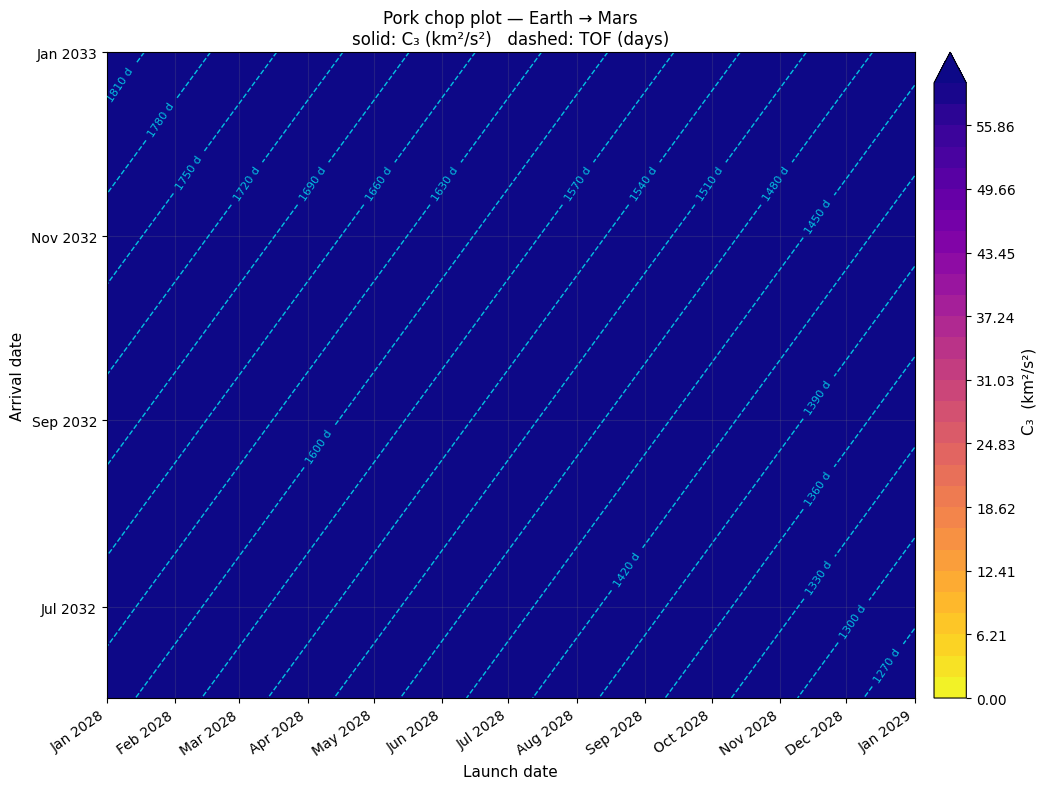

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm
import numpy as np

# ── Clip C3 to a readable range ───────────────────────────────────────
C3_MAX = 60.0   # km²/s² — adjust if your min C3 is higher
C3_plot = C3 #np.where((C3 > C3_MAX) | np.isnan(C3), np.nan, C3)

# ── Build date axes ───────────────────────────────────────────────────
import matplotlib.dates as mdates
launch_dts  = [t.to_datetime() for t in launch_dates]
arrival_dts = [t.to_datetime() for t in arrival_dates]
L, A = np.meshgrid(mdates.date2num(launch_dts),
                   mdates.date2num(arrival_dts), indexing='ij')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

# Filled C3 background
levels_fill = np.linspace(0, C3_MAX, 30)
cf = ax.contourf(L, A, C3_plot, levels=levels_fill,
                 cmap='plasma_r', extend='max')
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('C₃  (km²/s²)', fontsize=11)

# Solid C3 contour lines + labels
c3_line_levels = np.linspace(5, C3_MAX, 10)
cs = ax.contour(L, A, C3_plot, levels=c3_line_levels,
                colors='white', linewidths=0.8, alpha=0.6)
ax.clabel(cs, fmt='%.0f', fontsize=8, inline=True)

# Dashed TOF contour lines + labels
tof_levels = np.arange(100, int(np.nanmax(TOF)) + 1, 30)
tof_cs = ax.contour(L, A, TOF, levels=tof_levels,
                    colors='cyan', linewidths=1.0,
                    linestyles='dashed', alpha=0.75)
ax.clabel(tof_cs, fmt='%d d', fontsize=8, inline=True)

# ── Format axes as calendar dates ─────────────────────────────────────
ax.xaxis_date()
ax.yaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.yaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=35)

ax.set_xlabel('Launch date', fontsize=11)
ax.set_ylabel('Arrival date', fontsize=11)
ax.set_title('Pork chop plot — Earth → Mars\n'
             'solid: C₃ (km²/s²)   dashed: TOF (days)',
             fontsize=12)
ax.grid(color='gray', alpha=0.2)

plt.tight_layout()
# plt.savefig('pork_chop.png', dpi=150, bbox_inches='tight')
plt.show()